# Proyecto Final - Clasificador Multi-Clase

## Configuración e importaciones

In [1]:
import os, json, time, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
AVG          = "macro"
BITACORA     = "bitacora_experimentos.csv"
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Versiones — pandas", pd.__version__, "| xgboost", __import__("xgboost").__version__,
      "| tensorflow", tf.__version__)

Versiones — pandas 2.2.2 | xgboost 3.2.0 | tensorflow 2.17.0


## Carga del dataset

In [2]:
from ucimlrepo import fetch_ucirepo

_ds   = fetch_ucirepo(id=602)
X     = _ds.data.features.copy()
y_raw = _ds.data.targets.iloc[:, 0].copy()

feature_names = list(X.columns)
print("Dataset cargado vía ucimlrepo (UCI ID 602).")
print("Dimensiones de X:", X.shape, "| n clases:", y_raw.nunique())
X.head()

Dataset cargado vía ucimlrepo (UCI ID 602).
Dimensiones de X: (13611, 16) | n clases: 7


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


## Exploración

In [3]:
print("Shape:", X.shape)
print("\nTipos de dato (todas numéricas, sin categóricas a codificar en X):")
print(X.dtypes.value_counts())

print("\nValores nulos en features:", int(X.isnull().sum().sum()))
print("Valores nulos en target  :", int(y_raw.isnull().sum()))

dist = y_raw.value_counts()
print("\nDistribución de clases:")
print(dist)
print("\nRazón de desbalance (mayor/menor): %.1f : 1" % (dist.max() / dist.min()))

Shape: (13611, 16)

Tipos de dato (todas numéricas, sin categóricas a codificar en X):
float64    14
int64       2
Name: count, dtype: int64

Valores nulos en features: 0
Valores nulos en target  : 0

Distribución de clases:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Razón de desbalance (mayor/menor): 6.8 : 1


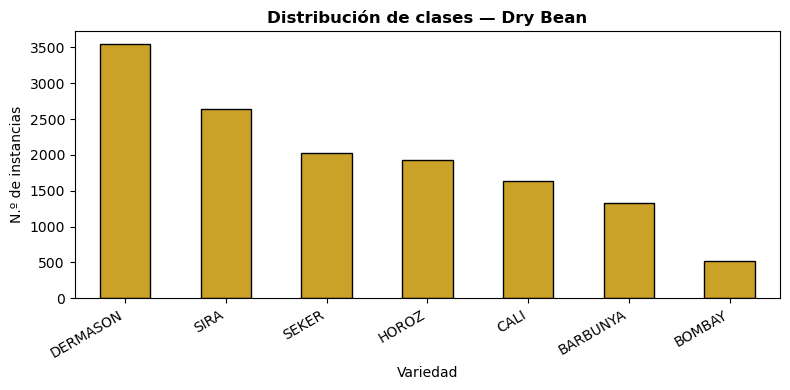

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
dist.sort_values(ascending=False).plot.bar(ax=ax, color="#C9A227", edgecolor="black")
ax.set_title("Distribución de clases — Dry Bean", fontweight="bold")
ax.set_ylabel("N.º de instancias"); ax.set_xlabel("Variedad")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.show()

**Observaciones de la exploración**

- El dataset está **limpio: 0 nulos** y todas las features son numéricas. Por tanto, **no hay imputación ni encoding de features que documentar** (a diferencia de otros candidatos como Penguins); la preparación se concentra en el encoding del *target*, el escalado para la red y el split estratificado.
- Confirma el **desbalance moderado**: Dermason domina y Bombay es la clase más escasa. Esto justifica seleccionar por **macro**, que pondera todas las clases por igual.


## Preparación de datos

In [5]:
le = LabelEncoder()
y  = le.fit_transform(y_raw)
clases = list(le.classes_)
print("Mapeo de clases:", dict(enumerate(clases)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

scaler     = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporción de clases preservada (train vs test):")
print(pd.DataFrame({"train": pd.Series(y_train).value_counts(normalize=True).sort_index(),
                    "test":  pd.Series(y_test).value_counts(normalize=True).sort_index()}).round(3))

Mapeo de clases: {0: 'BARBUNYA', 1: 'BOMBAY', 2: 'CALI', 3: 'DERMASON', 4: 'HOROZ', 5: 'SEKER', 6: 'SIRA'}
Train: (10888, 16) | Test: (2723, 16)
Proporción de clases preservada (train vs test):
   train   test
0  0.097  0.097
1  0.038  0.038
2  0.120  0.120
3  0.261  0.260
4  0.142  0.142
5  0.149  0.149
6  0.194  0.194


## Bitácora de experimentos — función de registro

In [6]:
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

def metricas(y_true, y_pred, sufijo):
    return {
        f"precision_{sufijo}": precision_score(y_true, y_pred, average=AVG, zero_division=0),
        f"recall_{sufijo}":    recall_score(y_true, y_pred, average=AVG, zero_division=0),
        f"f1_{sufijo}":        f1_score(y_true, y_pred, average=AVG, zero_division=0),
        f"accuracy_{sufijo}":  accuracy_score(y_true, y_pred),
    }

def registrar(exp_id, modelo, hiperparams, arquitectura,
              y_tr_pred, y_te_pred, segundos=None):
    fila = {"experimento_id": exp_id, "modelo": modelo,
            "hiperparametros": json.dumps(hiperparams, ensure_ascii=False),
            "arquitectura": arquitectura,
            "corrida": RUN_ID,
            "fecha_hora": datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
    fila.update(metricas(y_train, y_tr_pred, "train"))   # métricas en TRAIN
    fila.update(metricas(y_test,  y_te_pred, "test"))    # métricas en TEST
    pd.DataFrame([fila]).to_csv(
        BITACORA, mode="a", header=not os.path.exists(BITACORA), index=False)
    return fila

print("RUN_ID de esta corrida:", RUN_ID)

RUN_ID de esta corrida: 20260630_223441


### Random Forest - Experimentos

In [7]:
rf_configs = [
    {"n_estimators": 100, "max_depth": 3}, 
    {"n_estimators": 200, "max_depth": 8},
    {"n_estimators": 300, "max_depth": None}, 
    {"n_estimators": 200, "max_depth": 12, "min_samples_leaf": 5},                     
    {"n_estimators": 400, "max_depth": 16, "max_features": "sqrt", "criterion": "entropy"},
    {"n_estimators": 300, "max_depth": 6,  "min_samples_leaf": 2},
]

for i, cfg in enumerate(rf_configs, start=1):
    t0 = time.time()
    model = RandomForestClassifier(**cfg, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    f = registrar(f"RF_{i:02d}", "random_forest", cfg, "",
                  model.predict(X_train), model.predict(X_test), time.time() - t0)
    print(f"RF_{i:02d}  f1_train={f['f1_train']:.4f}  f1_test={f['f1_test']:.4f}")

RF_01  f1_train=0.6181  f1_test=0.6163
RF_02  f1_train=0.9497  f1_test=0.9291
RF_03  f1_train=1.0000  f1_test=0.9342
RF_04  f1_train=0.9648  f1_test=0.9312
RF_05  f1_train=1.0000  f1_test=0.9341
RF_06  f1_train=0.9153  f1_test=0.9042


### XGBoost - Experimentos

In [8]:
xgb_common = dict(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", eval_metric="mlogloss")
xgb_configs = [
    {"n_estimators": 100, "max_depth": 3,  "learning_rate": 0.3},
    {"n_estimators": 300, "max_depth": 6,  "learning_rate": 0.1},
    {"n_estimators": 500, "max_depth": 10, "learning_rate": 0.3},
    {"n_estimators": 300, "max_depth": 4,  "learning_rate": 0.05,
     "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 2},
    {"n_estimators": 400, "max_depth": 6,  "learning_rate": 0.1,
     "subsample": 0.9, "colsample_bytree": 0.7, "reg_lambda": 1},
    {"n_estimators": 200, "max_depth": 8,  "learning_rate": 0.2, "subsample": 0.85},
]

for i, cfg in enumerate(xgb_configs, start=1):
    t0 = time.time()
    model = XGBClassifier(**cfg, **xgb_common).fit(X_train, y_train)
    f = registrar(f"XGB_{i:02d}", "xgboost", cfg, "",
                  model.predict(X_train), model.predict(X_test), time.time() - t0)
    print(f"XGB_{i:02d}  f1_train={f['f1_train']:.4f}  f1_test={f['f1_test']:.4f}")

XGB_01  f1_train=0.9755  f1_test=0.9351
XGB_02  f1_train=0.9999  f1_test=0.9361
XGB_03  f1_train=1.0000  f1_test=0.9327
XGB_04  f1_train=0.9725  f1_test=0.9365
XGB_05  f1_train=1.0000  f1_test=0.9359
XGB_06  f1_train=1.0000  f1_test=0.9341


### Red Neuronal - Experimentos

In [9]:
def build_nn(hidden, dropout=0.0, lr=0.001, n_features=16, n_classes=7):
    m = keras.Sequential([keras.Input(shape=(n_features,))])
    for h in hidden:
        m.add(layers.Dense(h, activation="relu"))
        if dropout > 0:
            m.add(layers.Dropout(dropout))
    m.add(layers.Dense(n_classes, activation="softmax"))
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

nn_configs = [
    {"id": "NN_01", "hidden": [16],          "dropout": 0.0, "lr": 0.001, "batch": 32,  "epochs": 20},
    {"id": "NN_02", "hidden": [64, 32],      "dropout": 0.0, "lr": 0.001, "batch": 32,  "epochs": 80},
    {"id": "NN_03", "hidden": [128, 64, 32], "dropout": 0.0, "lr": 0.001, "batch": 64,  "epochs": 150}, 
    {"id": "NN_04", "hidden": [128, 64],     "dropout": 0.3, "lr": 0.001, "batch": 32,  "epochs": 100},
    {"id": "NN_05", "hidden": [256, 128],    "dropout": 0.0, "lr": 0.01,  "batch": 128, "epochs": 100},
    {"id": "NN_06", "hidden": [64, 64, 32],  "dropout": 0.2, "lr": 0.001, "batch": 64,  "epochs": 120},
]

for cfg in nn_configs:
    tf.random.set_seed(RANDOM_STATE)
    t0 = time.time()
    model = build_nn(cfg["hidden"], cfg["dropout"], cfg["lr"])
    model.fit(X_train_sc, y_train, epochs=cfg["epochs"], batch_size=cfg["batch"], verbose=0)
    arq = f"[16->{'->'.join(map(str, cfg['hidden']))}->7] relu/softmax, dropout={cfg['dropout']}"
    hp  = {k: cfg[k] for k in ("hidden", "dropout", "lr", "batch", "epochs")}
    f = registrar(cfg["id"], "neural_network", hp, arq,
                  model.predict(X_train_sc, verbose=0).argmax(1),
                  model.predict(X_test_sc,  verbose=0).argmax(1), time.time() - t0)
    print(f"{cfg['id']}  f1_train={f['f1_train']:.4f}  f1_test={f['f1_test']:.4f}")

NN_01  f1_train=0.9414  f1_test=0.9352
NN_02  f1_train=0.9550  f1_test=0.9367
NN_03  f1_train=0.9681  f1_test=0.9359
NN_04  f1_train=0.9536  f1_test=0.9382
NN_05  f1_train=0.9685  f1_test=0.9320
NN_06  f1_train=0.9519  f1_test=0.9349


## Bitácora

In [10]:
bit = pd.read_csv(BITACORA)
bit = bit.drop_duplicates(subset=["corrida", "experimento_id"], keep="last")
print("Total de filas en bitácora:", len(bit),
      "| corridas distintas:", bit["corrida"].nunique())
cols_show = ["experimento_id", "modelo", "f1_train", "f1_test",
             "accuracy_test", "precision_test", "recall_test"]
bit[cols_show].round(4)

Total de filas en bitácora: 18 | corridas distintas: 1


,experimento_id,modelo,f1_train,f1_test,accuracy_test,precision_test,recall_test
0,RF_01,random_forest,0.6181,0.6163,0.7826,0.7087,0.6527
1,RF_02,random_forest,0.9497,0.9291,0.9163,0.9333,0.9257
2,RF_03,random_forest,1.0000,0.9342,0.9218,0.9361,0.9325
3,RF_04,random_forest,0.9648,0.9312,0.9185,0.9339,0.9289
4,RF_05,random_forest,1.0000,0.9341,0.9225,0.9364,0.9321
5,RF_06,random_forest,0.9153,0.9042,0.8953,0.9104,0.9000
6,XGB_01,xgboost,0.9755,0.9351,0.9229,0.9375,0.9329
7,XGB_02,xgboost,0.9999,0.9361,0.9243,0.9385,0.9340
8,XGB_03,xgboost,1.0000,0.9327,0.9196,0.9343,0.9312
9,XGB_04,xgboost,0.9725,0.9365,0.9236,0.9390,0.9341


## Mejor modelo por familia

In [11]:
def mejor_de(modelo):
    sub = bit[bit["modelo"] == modelo]
    return sub.loc[sub["f1_test"].idxmax()]

mrf, mxgb, mnn = mejor_de("random_forest"), mejor_de("xgboost"), mejor_de("neural_network")
for nombre, row in [("Random Forest", mrf), ("XGBoost", mxgb), ("Red Neuronal", mnn)]:
    print(f"Mejor {nombre:14s}: {row['experimento_id']}  | f1_test={row['f1_test']:.4f}  | {row['hiperparametros']}")

rf_params  = json.loads(mrf["hiperparametros"])
best_rf    = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

xgb_params = json.loads(mxgb["hiperparametros"])
best_xgb   = XGBClassifier(**xgb_params, **xgb_common).fit(X_train, y_train)

nn_params  = json.loads(mnn["hiperparametros"])
tf.random.set_seed(RANDOM_STATE)
best_nn    = build_nn(nn_params["hidden"], nn_params["dropout"], nn_params["lr"])
best_nn.fit(X_train_sc, y_train, epochs=nn_params["epochs"], batch_size=nn_params["batch"], verbose=0)
print("\nLos 3 mejores modelos quedaron reconstruidos y entrenados sobre el train completo.")

Mejor Random Forest : RF_03  | f1_test=0.9342  | {"n_estimators": 300, "max_depth": null}
Mejor XGBoost       : XGB_04  | f1_test=0.9365  | {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 2}
Mejor Red Neuronal  : NN_04  | f1_test=0.9382  | {"hidden": [128, 64], "dropout": 0.3, "lr": 0.001, "batch": 32, "epochs": 100}

Los 3 mejores modelos quedaron reconstruidos y entrenados sobre el train completo.


## Feature importance - Mejor Random Forest y mejor XGBoost

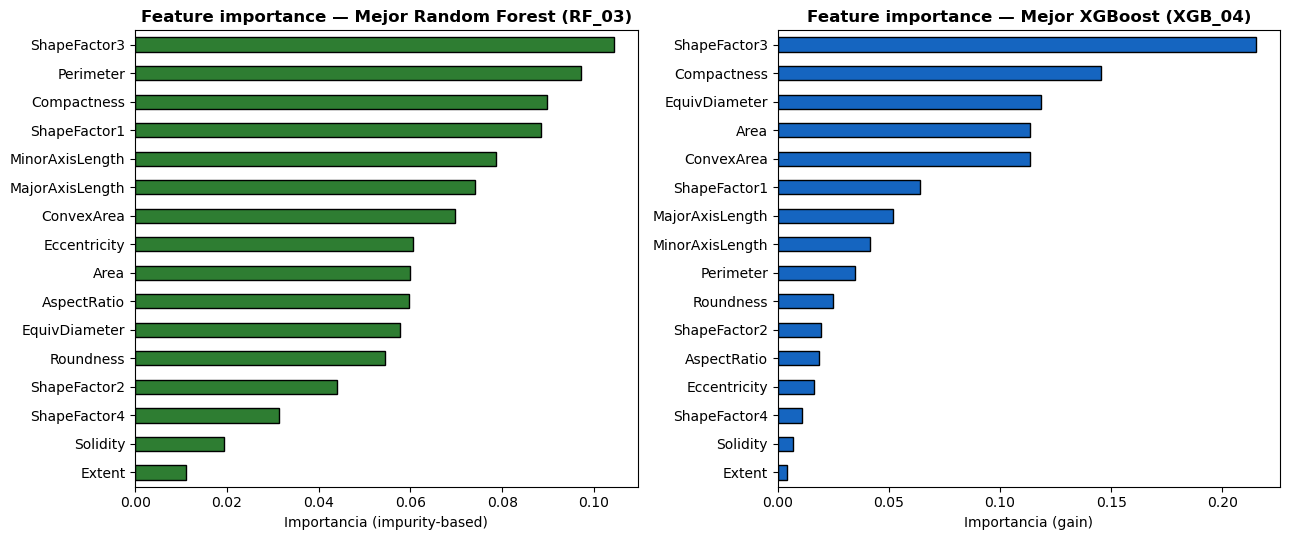

Top-5 Random Forest: ['ShapeFactor3', 'Perimeter', 'Compactness', 'ShapeFactor1', 'MinorAxisLength']
Top-5 XGBoost     : ['ShapeFactor3', 'Compactness', 'EquivDiameter', 'Area', 'ConvexArea']
Features compartidas en el Top-5: ['Compactness', 'ShapeFactor3']


,rank_RF,imp_RF,rank_XGB,imp_XGB
ShapeFactor3,1,0.1043,1,0.2152
Perimeter,2,0.0971,9,0.0346
Compactness,3,0.0898,2,0.1456
ShapeFactor1,4,0.0885,6,0.0641
MinorAxisLength,5,0.0787,8,0.0415
MajorAxisLength,6,0.0741,7,0.0520
ConvexArea,7,0.0698,5,0.1136
Eccentricity,8,0.0605,13,0.0164
Area,9,0.0599,4,0.1137
AspectRatio,10,0.0597,12,0.0185


In [12]:
imp_rf  = pd.Series(best_rf.feature_importances_,  index=feature_names).sort_values(ascending=False)
imp_xgb = pd.Series(best_xgb.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
imp_rf.sort_values().plot.barh(ax=axes[0], color="#2E7D32", edgecolor="black")
axes[0].set_title(f"Feature importance — Mejor Random Forest ({mrf['experimento_id']})", fontweight="bold")
axes[0].set_xlabel("Importancia (impurity-based)")
imp_xgb.sort_values().plot.barh(ax=axes[1], color="#1565C0", edgecolor="black")
axes[1].set_title(f"Feature importance — Mejor XGBoost ({mxgb['experimento_id']})", fontweight="bold")
axes[1].set_xlabel("Importancia (gain)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

comp = pd.DataFrame({
    "rank_RF":   pd.Series({f: r+1 for r, f in enumerate(imp_rf.index)}),
    "imp_RF":    imp_rf,
    "rank_XGB":  pd.Series({f: r+1 for r, f in enumerate(imp_xgb.index)}),
    "imp_XGB":   imp_xgb,
}).sort_values("rank_RF")
print("Top-5 Random Forest:", list(imp_rf.head(5).index))
print("Top-5 XGBoost     :", list(imp_xgb.head(5).index))
top5_rf, top5_xgb = set(imp_rf.head(5).index), set(imp_xgb.head(5).index)
print("Features compartidas en el Top-5:", sorted(top5_rf & top5_xgb))
comp.round(4)

**Interpretación del feature importance**

Ambos modelos apoyan la clasificación principalmente en variables asociadas al tamaño del grano, como área, perímetro, área convexa, diámetro equivalente y longitud del eje mayor, así como en variables relacionadas con su forma, entre ellas compacidad, factores de forma y redondez. Este comportamiento es coherente con el dominio del problema, ya que las variedades de frijol suelen diferenciarse por sus dimensiones y proporciones geométricas. Por ejemplo, la clase Bombay se caracteriza por granos de mayor tamaño, mientras que variedades como Sira, Dermason y Seker presentan tamaños más reducidos y rasgos morfológicos más similares, lo que puede dificultar su separación.

La comparación entre los rankings de importancia muestra coincidencias en las variables más relevantes, aunque con diferencias en el orden y en el peso asignado por cada modelo. Esto puede explicarse por dos aspectos principales. En primer lugar, la alta correlación entre varias variables morfológicas provoca que la importancia se distribuya de manera distinta entre predictores que contienen información similar. En segundo lugar, cada algoritmo calcula la importancia de forma diferente: Random Forest suele basarse en la reducción de impureza, mientras que XGBoost utiliza la ganancia asociada a las divisiones del modelo. Por esta razón, las diferencias entre rankings no necesariamente indican contradicción, sino distintas formas de repartir la contribución predictiva entre variables relacionadas.

Finalmente, las variables que presentan baja importancia en ambos modelos podrían considerarse candidatas para un análisis posterior de selección de características. No obstante, su eliminación debería validarse empíricamente, comparando el desempeño del modelo antes y después de retirarlas, para confirmar que su exclusión no afecte de forma relevante la capacidad predictiva.

## Ensamble - Majority voting con bootstrap

In [13]:
f1_individual = {"rf": mrf["f1_test"], "xgb": mxgb["f1_test"], "nn": mnn["f1_test"]}
orden = ["rf", "xgb", "nn"]
prioridad = int(np.argmax([f1_individual[k] for k in orden]))
print("F1 individual:", {k: round(v, 4) for k, v in f1_individual.items()})
print("Modelo prioritario para desempate:", orden[prioridad])

def voto_mayoritario(stack, prioridad_idx):
    out = np.empty(stack.shape[1], dtype=int)
    for j in range(stack.shape[1]):
        votos = stack[:, j]
        clases_v, counts = np.unique(votos, return_counts=True)
        if counts.max() == 1:
            out[j] = votos[prioridad_idx]
        else:
            out[j] = clases_v[counts.argmax()]
    return out

n   = len(X_train)
rng = np.random.default_rng(RANDOM_STATE)

idx_rf  = rng.integers(0, n, n)
boot_rf = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, n_jobs=-1).fit(
            X_train.iloc[idx_rf], y_train[idx_rf])

idx_xgb  = rng.integers(0, n, n)
boot_xgb = XGBClassifier(**xgb_params, **xgb_common).fit(
            X_train.iloc[idx_xgb], y_train[idx_xgb])

idx_nn = rng.integers(0, n, n)
tf.random.set_seed(RANDOM_STATE)
boot_nn = build_nn(nn_params["hidden"], nn_params["dropout"], nn_params["lr"])
boot_nn.fit(X_train_sc[idx_nn], y_train[idx_nn], epochs=nn_params["epochs"],
            batch_size=nn_params["batch"], verbose=0)

pred_train = np.vstack([boot_rf.predict(X_train),
                        boot_xgb.predict(X_train),
                        boot_nn.predict(X_train_sc, verbose=0).argmax(1)])
pred_test  = np.vstack([boot_rf.predict(X_test),
                        boot_xgb.predict(X_test),
                        boot_nn.predict(X_test_sc,  verbose=0).argmax(1)])

ens_train = voto_mayoritario(pred_train, prioridad)
ens_test  = voto_mayoritario(pred_test,  prioridad)

ens_metrics_tr = metricas(y_train, ens_train, "train")
ens_metrics_te = metricas(y_test,  ens_test,  "test")
print(f"\nEnsamble  F1_train={ens_metrics_tr['f1_train']:.4f}  F1_test={ens_metrics_te['f1_test']:.4f}")

registrar("ENS_01", "ensemble_majority_voting",
          {"bases": [mrf['experimento_id'], mxgb['experimento_id'], mnn['experimento_id']],
           "desempate": orden[prioridad]},
          "bootstrap por modelo + voto mayoritario", ens_train, ens_test)
print("Fila del ensamble agregada a la bitácora.")

F1 individual: {'rf': 0.9342, 'xgb': 0.9365, 'nn': 0.9382}
Modelo prioritario para desempate: nn

Ensamble  F1_train=0.9681  F1_test=0.9351
Fila del ensamble agregada a la bitácora.


## Comparación final y diagnóstico

In [14]:
def diagnostico(f1_tr, f1_te, gap_thr=0.05, low_thr=0.88):
    gap = f1_tr - f1_te
    if f1_tr < low_thr and f1_te < low_thr:
        return "Underfit"
    if gap > gap_thr:
        return "Overfit"
    return "Bien ajustado"

filas = [
    ("Mejor Random Forest",        mrf["f1_train"],  mrf["f1_test"]),
    ("Mejor XGBoost",              mxgb["f1_train"], mxgb["f1_test"]),
    ("Mejor Red Neuronal",         mnn["f1_train"],  mnn["f1_test"]),
    ("Ensamble (majority voting)", ens_metrics_tr["f1_train"], ens_metrics_te["f1_test"]),
]
tabla = pd.DataFrame(filas, columns=["Modelo", "F1 (train)", "F1 (test)"])
tabla["Δ"]           = (tabla["F1 (train)"] - tabla["F1 (test)"]).round(3)
tabla["Diagnóstico"] = [diagnostico(a, b) for a, b in zip(tabla["F1 (train)"], tabla["F1 (test)"])]
tabla[["F1 (train)", "F1 (test)"]] = tabla[["F1 (train)", "F1 (test)"]].round(4)
tabla

,Modelo,F1 (train),F1 (test),Δ,Diagnóstico
0,Mejor Random Forest,1.0000,0.9342,0.066,Overfit
1,Mejor XGBoost,0.9725,0.9365,0.036,Bien ajustado
2,Mejor Red Neuronal,0.9536,0.9382,0.015,Bien ajustado
3,Ensamble (majority voting),0.9681,0.9351,0.033,Bien ajustado


In [15]:
print("NOTAS DE DIAGNÓSTICO\n" + "=" * 60)
for _, r in tabla.iterrows():
    d = r["Diagnóstico"]; delta = r["Δ"]
    if d == "Overfit":
        nota = f"F1 alto en train ({r['F1 (train)']:.3f}) que cae en test ({r['F1 (test)']:.3f}), Δ={delta} → memoriza más de lo que generaliza; convendría más regularización."
    elif d == "Underfit":
        nota = f"F1 bajo en train y test (Δ={delta}) → el modelo no captura la estructura; falta capacidad/epochs."
    else:
        nota = f"F1 alto y cercano en train/test (Δ={delta}) → generaliza bien."
    print(f"\n• {r['Modelo']}: {nota}")

NOTAS DE DIAGNÓSTICO

• Mejor Random Forest: F1 alto en train (1.000) que cae en test (0.934), Δ=0.066 → memoriza más de lo que generaliza; convendría más regularización.

• Mejor XGBoost: F1 alto y cercano en train/test (Δ=0.036) → generaliza bien.

• Mejor Red Neuronal: F1 alto y cercano en train/test (Δ=0.015) → generaliza bien.

• Ensamble (majority voting): F1 alto y cercano en train/test (Δ=0.033) → generaliza bien.


## Conclusión

In [16]:
mejor_familia  = tabla.iloc[:3].sort_values("F1 (test)", ascending=False).iloc[0]
f1_ens         = tabla.iloc[3]["F1 (test)"]
f1_mejor_indiv = tabla.iloc[:3]["F1 (test)"].max()
delta_ens      = tabla.iloc[3]["Δ"]
mejoro         = "no superó" if f1_ens < f1_mejor_indiv else "mejoró"
fam            = mejor_familia["Modelo"].replace("Mejor ", "")

lineas = [
 "CONCLUSIÓN",
 "==========",
 "Se entrenaron y compararon tres familias de modelos (Random Forest, XGBoost y una red",
 "neuronal) sobre el Dry Bean Dataset, un problema multi-clase de 7 variedades de frijol,",
 "usando un único split train-test 80/20 estratificado y F1-score macro como métrica",
 "consistente. Tras 18 experimentos (6 por familia) más un ensamble por voto mayoritario",
 "con bootstrap, estos fueron los resultados y aprendizajes:",
 "",
 f"- La familia con mejor F1 en test fue {fam} (F1_test={mejor_familia['F1 (test)']:.4f}), seguida de",
 f"  cerca por las otras dos. Las tres quedaron en un rango muy estrecho, lo que indica que el",
 "  problema es bien separable con las 16 features geométricas disponibles.",
 "",
 "- El diagnóstico train vs test fue más revelador que el F1 por sí solo. El mejor Random Forest",
 f"  fue elegido por su F1 máximo en test, pero quedó en sobreajuste (train=1.0000 vs test",
 f"  ={tabla.iloc[0]['F1 (test)']:.4f}, delta={tabla.iloc[0]['Δ']}): el criterio 'mejor F1 en test' no garantiza el mejor",
 "  ajuste. XGBoost y la red generalizaron mejor, con brechas pequeñas; la red fue el modelo",
 "  mejor equilibrado de todos.",
 "",
 f"- El ensamble {mejoro} el desempeño: obtuvo F1_test={f1_ens:.4f} frente al mejor individual",
 f"  ({f1_mejor_indiv:.4f}). Cuando una base ya generaliza muy bien, el voto mayoritario tiende a",
 f"  arrastrar el resultado hacia el promedio de los tres en lugar de superar al más fuerte; aun",
 f"  así quedó bien ajustado (delta={delta_ens}), cumpliendo su función de reducir varianza.",
 "",
 "- Qué aprendí: (1) un F1 alto en test puede convivir con sobreajuste, por lo que revisar la",
 "  brecha train-test es indispensable para juzgar un modelo; (2) con multicolinealidad fuerte,",
 "  Random Forest y XGBoost coinciden en las features dominantes de tamaño y forma, pero difieren",
 "  en el orden por cómo cada algoritmo reparte la importancia; y (3) ensamblar no mejora",
 "  automáticamente los resultados: con un modelo individual ya sólido, el voto mayoritario",
 "  puede incluso quedar por debajo de él.",
]
print(chr(10).join(lineas))

CONCLUSIÓN
Se entrenaron y compararon tres familias de modelos (Random Forest, XGBoost y una red
neuronal) sobre el Dry Bean Dataset, un problema multi-clase de 7 variedades de frijol,
usando un único split train-test 80/20 estratificado y F1-score macro como métrica
consistente. Tras 18 experimentos (6 por familia) más un ensamble por voto mayoritario
con bootstrap, estos fueron los resultados y aprendizajes:

- La familia con mejor F1 en test fue Red Neuronal (F1_test=0.9382), seguida de
  cerca por las otras dos. Las tres quedaron en un rango muy estrecho, lo que indica que el
  problema es bien separable con las 16 features geométricas disponibles.

- El diagnóstico train vs test fue más revelador que el F1 por sí solo. El mejor Random Forest
  fue elegido por su F1 máximo en test, pero quedó en sobreajuste (train=1.0000 vs test
  =0.9342, delta=0.066): el criterio 'mejor F1 en test' no garantiza el mejor
  ajuste. XGBoost y la red generalizaron mejor, con brechas pequeñas; la red 